## Визуализация данных

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Визуализация данных".
* https://numpy.org/doc/stable/reference/generated/numpy.load.html
* https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html
* https://matplotlib.org/stable/gallery/subplots_axes_and_figures/shared_axis_demo.html
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html#pandas.DataFrame.plot
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.pie.html
* https://seaborn.pydata.org/examples/index.html
* https://matplotlib.org/stable/tutorials/colors/colormaps.html

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## Задачи для совместного разбора

## Лабораторная работа №5

__Данная работа подразумевает построение рисунков. В связи с этим задания, для которых не будет виден результат выполнения ячеек (получившиеся рисунки), засчитаны не будут вне зависимости от правильности решения.__

### Визуализация данных при помощи пакета `matplotlib`

__В данном блоке задач не разрешается использовать другие пакеты для визуализации, кроме `matplotlib`.__

1\. В файле `average_ratings.npy` содержится информация о среднем рейтинге 3 рецептов за период с 01.01.2019 по 30.12.2021. При помощи пакета `matplotlib` в _одной системе координат_ (на одной картинке) изобразите три временных ряда, соответствующих средним рейтингам этих рецептов. 

По горизонтальной оси располагается номер дня (0, 1, 2, ...), по вертикальной - средний рейтинг рецептов в этот день. 

Названия рецептов и их индексы в файле `average_ratings.npy`:
```
0: waffle iron french toast
1: zwetschgenkuchen bavarian plum cake
2: lime tea
```

Результатом работы является визуализация, на которой:
* добавлена подпись горизонтальной оси с текстом "Номер дня"
* добавлена подпись вертикальной оси с текстом "Средний рейтинг"
* добавлена подпись рисунка с текстом "Изменение среднего рейтинга трех рецептов"
* каждый из временных рядов имеет уникальный цвет
* добавлена легенда, на которой отображается название каждого из рецептов

_Примечание_ : для считывания файла воспользуйтесь функцией `np.load`.

In [5]:
import numpy as np

In [6]:
average_ratings = np.load('05_visualization_data/average_ratings.npy')

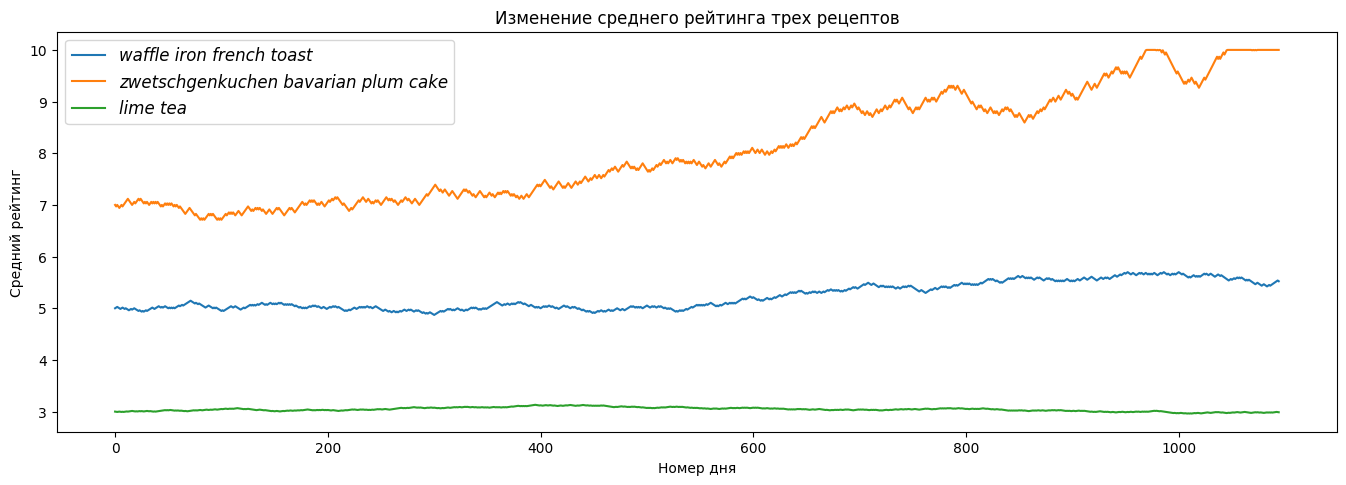

In [7]:
fig = plt.figure(figsize=(16, 5))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # [left, bottom, width, height]
plt.xlabel('Номер дня') # ось абсцисс - горизонтальная
plt.ylabel('Средний рейтинг') # оси ординат - вертикальная
plt.title('Изменение среднего рейтинга трех рецептов'); # заголовок
plt.plot(range(len(average_ratings[0])), average_ratings[0], label='waffle iron french toast') 
plt.plot(range(len(average_ratings[1])), average_ratings[1], label='zwetschgenkuchen bavarian plum cake')
plt.plot(range(len(average_ratings[2])), average_ratings[2], label='lime tea')
plt.legend(prop={'size': 12, 'style': 'italic'} );

2\. Измените визуализацию, полученную в задании 1, таким образом, чтобы по горизонтальной оси отображались года, а между двумя соседними годами располагались засечки, соответствующие месяцам. Для этого создайте диапазон дат от 01.01.2019 по 30.12.2021 с шагом в один день (например, [вот так](https://pandas.pydata.org/docs/reference/api/pandas.date_range.html)) и используйте этот диапазон при вызове метода `plot`. Далее настройте `major_locator` и `minor_locator` горизонтальной оси (подробнее см. [здесь](https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html))

Примените к получившемуся рисунку цвета графиков, подписи, легенду из задания 1. Измените подпись горизонтальной оси, написав там слово "Дата".


In [8]:
import matplotlib.dates as mdates

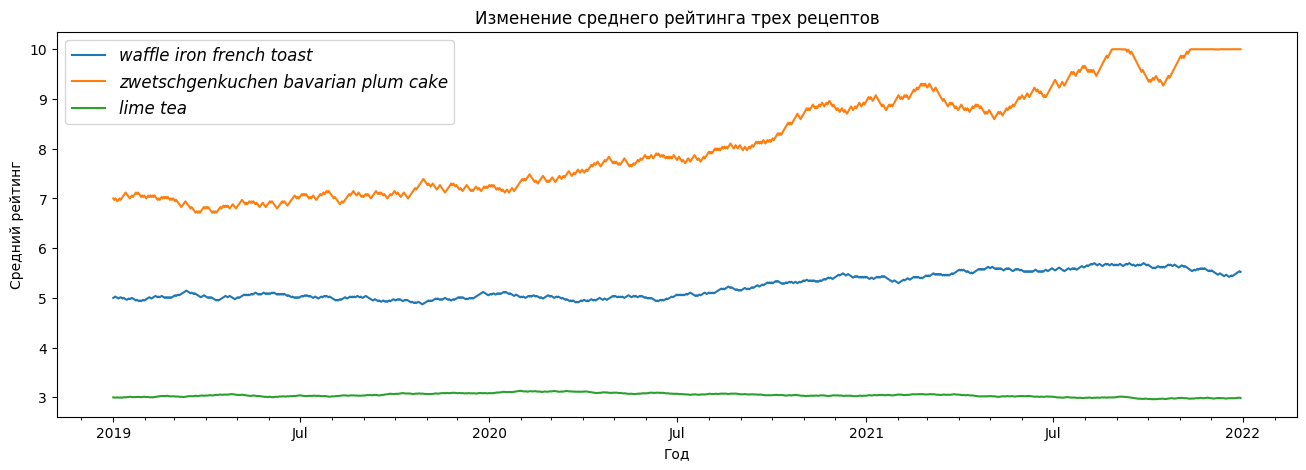

In [11]:
data = pd.date_range(start='1/1/2019', end='12/30/2021')
fig, ax = plt.subplots(figsize=(16, 5))
plt.xlabel('Год')
plt.ylabel('Средний рейтинг')
plt.title('Изменение среднего рейтинга трех рецептов');
plt.plot(data, average_ratings[0], label='waffle iron french toast')
plt.plot(data, average_ratings[1], label='zwetschgenkuchen bavarian plum cake')
plt.plot(data, average_ratings[2], label='lime tea')
plt.legend(prop={'size': 12, 'style': 'italic'} );
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

3\. Измените визуализацию, полученную в задании 2, разбив одну картинку на три, расположенных друг под другом. Три изображения должны иметь одну общую горизонтальную ось (каждое изображение засечки в нижней части, но значения этих засечек находятся только под самым нижним изображением). Примените к получившемуся рисунку цвета графиков, подписи, легенду из задания 2. 

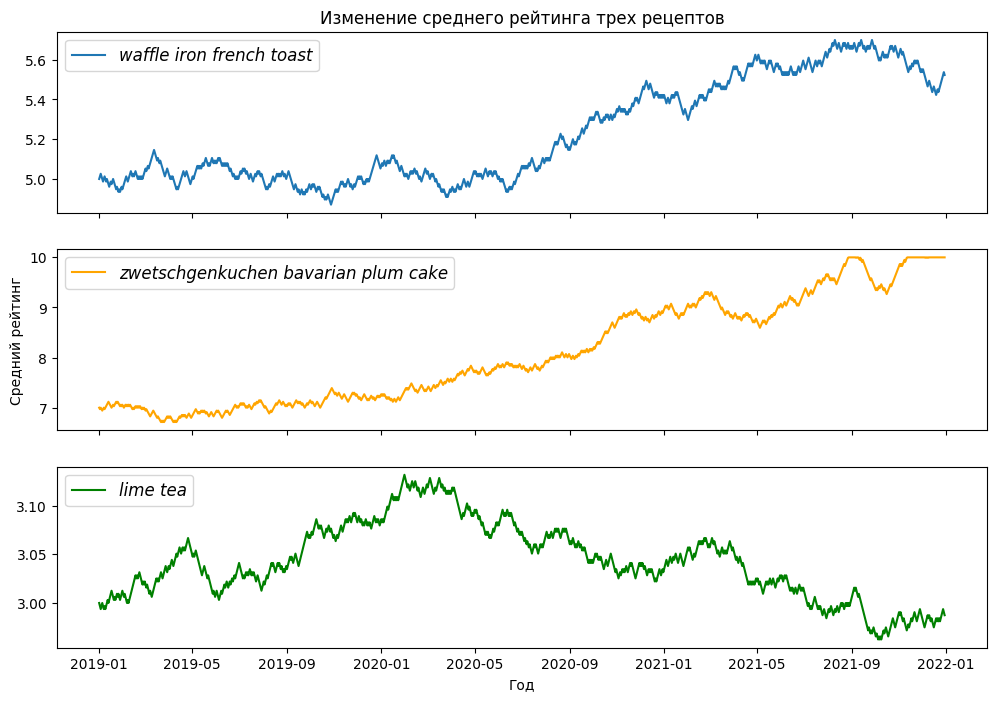

In [12]:

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 8)) # sharex=True - общая ось абсцисс
axes[0].plot(data, average_ratings[0], label='waffle iron french toast')
axes[0].set_title('Изменение среднего рейтинга трех рецептов');
axes[0].legend(prop={'size': 12, 'style': 'italic'} );

# Create the second subplot
axes[1].plot(data, average_ratings[1], label='zwetschgenkuchen bavarian plum cake', c='orange')
axes[1].legend(prop={'size': 12, 'style': 'italic'} );
axes[1].set_ylabel('Средний рейтинг')

# Create the third subplot
axes[2].plot(data, average_ratings[2], label='lime tea', c='g')
axes[2].set_xlabel('Год')
axes[2].legend(prop={'size': 12, 'style': 'italic'} , loc='upper left');


4\. В файле `visitors.npy` представлена информация о количестве посетителей сайта в течении первых 100 дней после объявления сайтом акции. Постройте график изменения количества пользователей в зависимости от дня в двух вариантах, расположенных рядом по горизонтале. В обоих случаях изобразите график в виде ломаной, но в первом случае оставьте линейный масштаб осей, а во втором случае сделайте вертикальную ось в логарифмическом масштабе. Добавьте на обе картинки подпись над этим графиком к текстом $y(x)=\lambda e^{-\lambda x}$

Добавьте на оба изображения красную горизонтальную линию на уровне $y=100$. Добавьте на обе картинки подпись над этой линией с текстом $y(x)=100$

Добавьте на оба изображения подписи осей; горизонтальную ось подпишите текстом "Количество дней с момента акции", вертикальную - "Число посетителей".

Добавьте общий заголовок для фигуры с текстом "Изменение количества пользователей в линейном и логарифмическом масштабе".


In [14]:
visitors = np.load('05_visualization_data/visitors.npy')
visitors

array([2311, 2023, 1839, 1523, 1371, 1217, 1098,  958,  862,  724,  654,
        558,  526,  454,  383,  372,  356,  274,  239,  236,  214,  179,
        180,  140,  138,  112,  102,  101,   74,   81,   70,   74,   53,
         57,   52,   44,   38,   30,   37,   27,   20,   21,   16,   16,
         12,    9,   13,   10,   13,    7,    5,    8,    6,    8,    9,
          4,    3,    4,    4,    2,    2,    3,    2,    2,    2,    2,
          2,    3,    2,    2,    3,    2,    2,    2,    2,    3,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2], dtype=int32)

Text(0.5, 0.98, 'Изменение количества пользователей в линейном и логарифмическом масштабе')

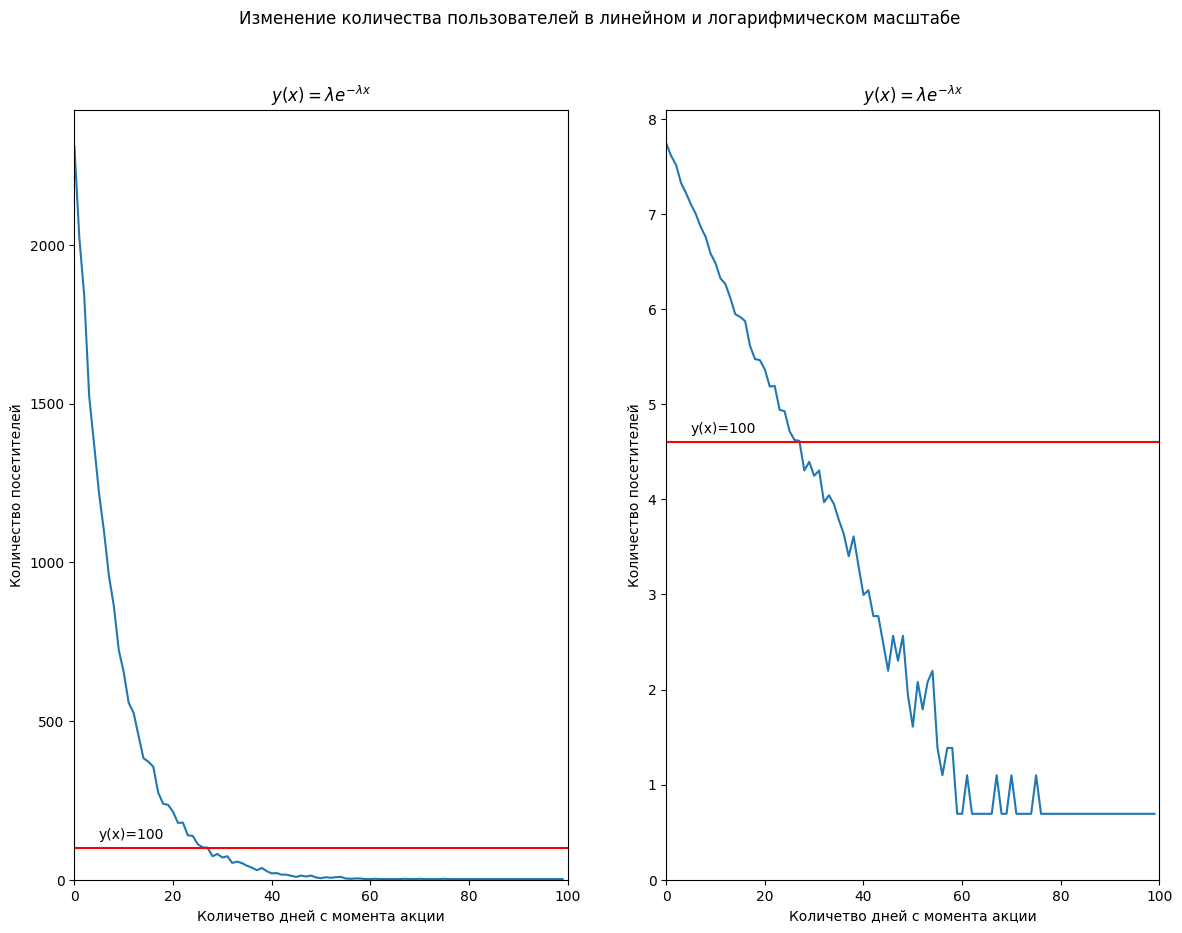

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10)) # 1 строка, 2 столбца 
axes[0].set_xlabel('Количетво дней с момента акции')
axes[0].set_ylabel('Количество посетителей')
axes[0].plot(np.arange(len(visitors)), visitors)
axes[0].plot([0, 100], 2*[100], 'r') 
axes[0].text(5, 130, 'y(x)=100')

axes[1].set_xlabel('Количетво дней с момента акции')
axes[1].set_ylabel('Количество посетителей')
axes[1].plot(np.arange(len(visitors)), np.log(visitors))
axes[1].plot([0, 100], 2*[np.log(100)], 'r')
axes[1].text(5, np.log(110), 'y(x)=100')

for ax in axes:
  ax.set_ylim(0)
  ax.set_xlim(0, 100)
  ax.set_title('$y(x)=λe^{−λx}$')
plt.suptitle('Изменение количества пользователей в линейном и логарифмическом масштабе')

### Визуализация данных на основе структур `pandas`.

Для продолжения работы загрузите таблицы recipes и reviews (__ЛР2__)

In [25]:
reviews = pd.read_csv('02_pandas_data/reviews_sample.csv', index_col=0)
recipes = pd.read_csv('02_pandas_data/recipes_sample.csv', parse_dates=['submitted'])

In [26]:
reviews

,user_id,recipe_id,date,rating,review
370476,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...
624300,431813,142201,2007-09-16,5,So simple and so tasty! I used a yellow capsi...
187037,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy..."
706134,2001852463,404716,2017-12-11,5,These are a favorite for the holidays and so e...
312179,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...
...,...,...,...,...,...
1013457,1270706,335534,2009-05-17,4,This recipe was great! I made it last night. I...
158736,2282344,8701,2012-06-03,0,This recipe is outstanding. I followed the rec...
1059834,689540,222001,2008-04-08,5,"Well, we were not a crowd but it was a fabulou..."
453285,2000242659,354979,2015-06-02,5,I have been a steak eater and dedicated BBQ gr...


In [27]:
recipes

,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,george s at the cove black bean soup,44123,90,35193,2002-10-25,NaN,an original recipe created by chef scott meska...,18.0
1,healthy for them yogurt popsicles,67664,10,91970,2003-07-26,NaN,my children and their friends ask for my homem...,NaN
2,i can t believe it s spinach,38798,30,1533,2002-08-29,NaN,"these were so go, it surprised even me.",8.0
3,italian gut busters,35173,45,22724,2002-07-27,NaN,my sister-in-law made these for us at a family...,NaN
4,love is in the air beef fondue sauces,84797,25,4470,2004-02-23,4.0,i think a fondue is a very romantic casual din...,NaN
...,...,...,...,...,...,...,...,...
29995,zurie s holey rustic olive and cheddar bread,267661,80,200862,2007-11-25,16.0,this is based on a french recipe but i changed...,10.0
29996,zwetschgenkuchen bavarian plum cake,386977,240,177443,2009-08-24,NaN,"this is a traditional fresh plum cake, thought...",11.0
29997,zwiebelkuchen southwest german onion cake,103312,75,161745,2004-11-03,NaN,this is a traditional late summer early fall s...,NaN
29998,zydeco soup,486161,60,227978,2012-08-29,NaN,this is a delicious soup that i originally fou...,NaN


5\. Назовем рецепты короткими, если они занимают строго меньше 5 минут; средними, если они занимают от 5 до 50 минут (не включая 50), и длинными, если они занимают от 50 минут и больше. Сгруппируйте все рецепты по данному признаку и для каждой группы посчитайте 2 величины: среднее количество шагов рецептов в группе и размер группы. При помощи методов структур `pandas` постройте столбчатую диаграмму, где каждый столбец означает группу (короткие, средние или длинные рецепты), а высота столбца обозначает среднее количество шагов рецептов в группе. Рядом по горизонтали разместите круговую диаграмму, на которой отображены размеры каждой из групп.

Добавьте следующие подписи:
* по горизонтальной оси под столбчатой диаграммой напишите "Группа рецептов"
* по вертикальной оси слева от столбчатой диаграммы напишите "Средняя длительность"
* над круговой диаграммой напишите "Размеры групп рецептов"

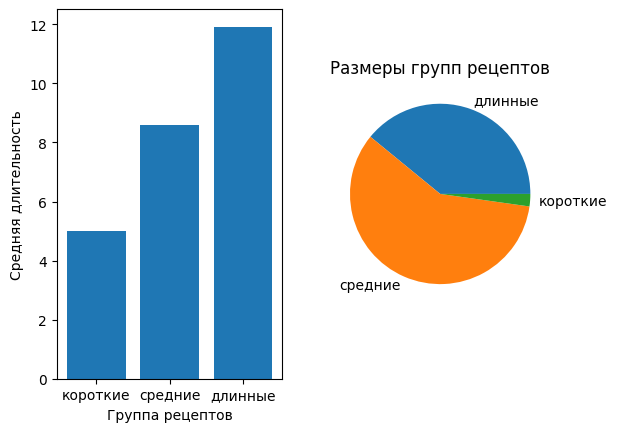

In [30]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2) # fig, (ax1, ax2) = plt.subplots(1, 2) - строим две диаграммы 

recipes['steps_kind'] = 'medium' # добавляем новый столбец со значением 'medium'
recipes.loc[recipes["minutes"] < 5, 'steps_kind'] = 'short' # меняем значение столбца 'steps_kind' на 'short' для строк, где значение столбца 'minutes' меньше 5
recipes.loc[recipes["minutes"] >= 50, 'steps_kind'] = 'long' # меняем значение столбца 'steps_kind' на 'long' для строк, где значение столбца 'minutes' больше или равно 50

recipes_grouped = recipes.groupby('steps_kind') # группируем по столбцу 'steps_kind'
mean_nsteps = recipes_grouped['n_steps'].mean() # считаем среднее значение столбца 'n_steps' для каждой группы

ax1.set_xlabel('Группа рецептов') 
ax1.set_ylabel('Средняя длительность')
ax1.bar(['короткие', 'средние', 'длинные'], [mean_nsteps['short'], mean_nsteps['medium'],  mean_nsteps['long']])

ax2.set_title('Размеры групп рецептов')
ax2.pie(recipes_grouped['n_steps'].count().values, labels=['длинные', 'средние', 'короткие']);

6\. Из всего множества отзывов оставьте только те, которые были даны в 2008 и 2009 годах. Воспользовавшись возможностями метода `pd.DataFrame.plot.hist`, постройте 2 гистограммы столбца `rating`. Гистограммы должны быть расположены рядом по горизонтали. Левая гистограмма соотвествует 2008 году, правая - 2009 году. Добавьте общую подпись для рисунка с текстом "Гистограммы рейтинга отзывов в 2008 и 2009 годах". Добейтесь того, чтобы подпись вертикальной оси правого рисунка не "наезжала" на левый рисунок.

In [41]:
reviews = pd.read_csv('02_pandas_data/reviews_sample.csv', index_col=0, parse_dates=['date'])
reviews

,user_id,recipe_id,date,rating,review
370476,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...
624300,431813,142201,2007-09-16,5,So simple and so tasty! I used a yellow capsi...
187037,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy..."
706134,2001852463,404716,2017-12-11,5,These are a favorite for the holidays and so e...
312179,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...
...,...,...,...,...,...
1013457,1270706,335534,2009-05-17,4,This recipe was great! I made it last night. I...
158736,2282344,8701,2012-06-03,0,This recipe is outstanding. I followed the rec...
1059834,689540,222001,2008-04-08,5,"Well, we were not a crowd but it was a fabulou..."
453285,2000242659,354979,2015-06-02,5,I have been a steak eater and dedicated BBQ gr...


In [42]:
reviews_2008_2009  = reviews[(reviews['date'] >= '2008-1-1') & (reviews['date'] <= '2009-12-31')]# отбираем строки, где значение столбца 'date' меньше 2010-01-01 и больше или равно 2008-01-01
reviews_2008_2009

,user_id,recipe_id,date,rating,review
187037,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy..."
312179,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...
1023302,308434,11252,2008-12-14,5,Oh Bergy! These wonderful little cakes are aw...
264646,151754,285773,2008-09-04,0,"This was a very moist cornbread, even two days..."
126930,379985,150499,2008-08-21,5,I really liked this recipe. It's perfect to ma...
...,...,...,...,...,...
532061,335737,36548,2008-04-22,5,If only there were more stars to give! Normall...
698638,1186693,394518,2009-12-09,0,I must have done something wrong! Mine were v...
344676,724631,314698,2008-10-14,5,"5 Stars, The Hunter said the mushrooms and sau..."
1013457,1270706,335534,2009-05-17,4,This recipe was great! I made it last night. I...


array([<AxesSubplot:title={'center':'2008'}>,
       <AxesSubplot:title={'center':'2009'}>], dtype=object)

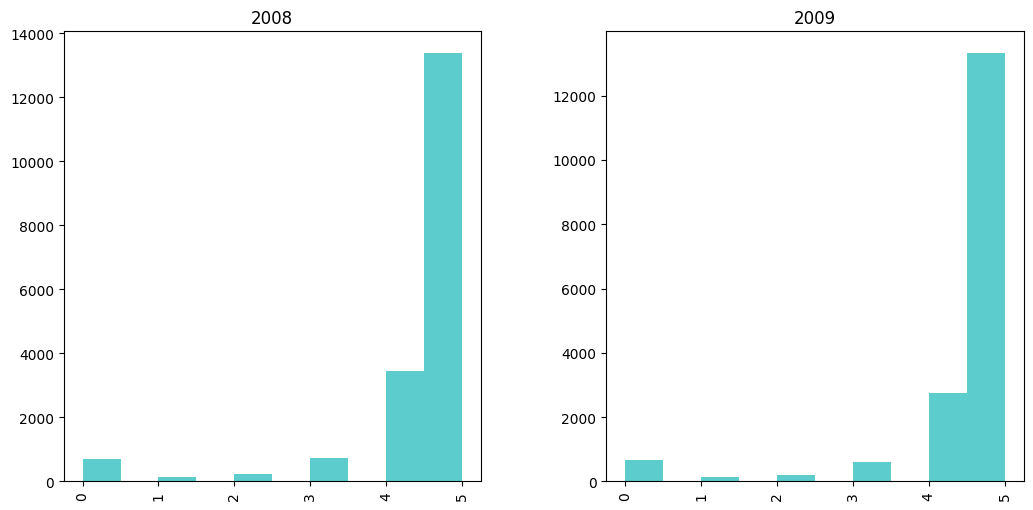

In [43]:
reviews_2008_2009.hist(column='rating', by=reviews_2008_2009['date'].dt.year, figsize=(12, 6), color='#5CCCCC')
# column - столбец, по которому строим гистограммы, by - столбец, по которому группируем, figsize - размер диаграммы, color - цвет диаграммы

### Визуализация данных при помощи пакета `seaborn`

7\. При помощи пакета `seaborn` постройте диаграмму рассеяния двух столбцов из таблицы `recipes`: `n_steps` и `n_ingredients`. Укажите в качестве группирующей переменной (hue) категориальную длительность рецепта (короткий, средний или длинные; см. задание 5). 

Добавьте заголовок рисунка "Диаграмма рассеяния n_steps и n_ingredients"

Прокомментируйте, наблюдается ли визуально линейная зависимость между двумя этими переменными. Ответ оставьте в виде текстовой ячейки под изображением.

In [44]:
import seaborn as sns
sns.set_style("whitegrid") # устанавливаем стиль сетки

Text(0.5, 1.0, 'Диаграмма рассеяния n_steps и n_ingredients')

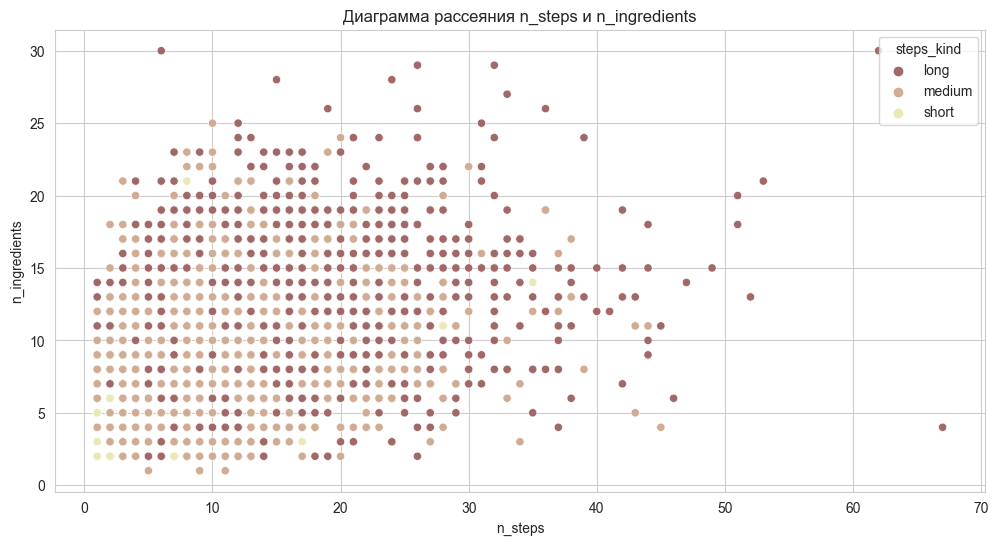

In [45]:
plt.figure(figsize=(12, 6)) # задаем размер диаграммы
sns.scatterplot(x = 'n_steps', y = 'n_ingredients', hue = "steps_kind", data=recipes, palette="pink") # строим диаграмму рассеяния
plt.title("Диаграмма рассеяния n_steps и n_ingredients")

In [48]:
# Линейная зависимость наблюдается, чем меньше ингредиентов, тем меньше шагов в приготовленнии блюда

8\. Объедините две таблицы `recipes` и `reviews` и постройте корреляционную матрицу на основе столбцов "minutes", "n_steps", "n_ingredients" и "rating". При помощи пакета `seaborn` визуализируйте полученную матрицу в виде тепловой карты (heatmap). 

Добавьте в ячейки тепловой карты подписи (значения к-та корреляции). Измените цветовую палитру на `YlOrRd`. 

Добавьте заголовок рисунка "Корреляционная матрица числовых столбцов таблиц recipes и reviews"

In [50]:
new_table = pd.merge(reviews, recipes, left_on='recipe_id', right_on='id', how='inner') # объединяем таблицы по столбцу 'recipe_id' и 'id'
new_table

,user_id,recipe_id,date,rating,review,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients,steps_kind
0,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...,salmon with tomatoes,57993,50,52543,2003-04-04,NaN,this savoury dish is very popular in andalusia...,NaN,long
1,86359,57993,2003-08-10,5,My sisters husband caught a salmon off the Que...,salmon with tomatoes,57993,50,52543,2003-04-04,NaN,this savoury dish is very popular in andalusia...,NaN,long
2,67026,57993,2005-06-11,5,I enjoyed this very much. Turned out pretty d...,salmon with tomatoes,57993,50,52543,2003-04-04,NaN,this savoury dish is very popular in andalusia...,NaN,long
3,371697,57993,2006-10-27,5,Delicious! Perfect blend of flavors. I didn'...,salmon with tomatoes,57993,50,52543,2003-04-04,NaN,this savoury dish is very popular in andalusia...,NaN,long
4,175286,57993,2004-12-29,5,Delicious! Made this last night with relative...,salmon with tomatoes,57993,50,52543,2003-04-04,NaN,this savoury dish is very popular in andalusia...,NaN,long
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126691,157617,94096,2004-08-14,5,wheeee!!! \r\nincredible!!!!\r\n;)\r\ntook a l...,vegetable pasta pie,94096,105,22174,2004-06-23,28.0,i've had this recipe for ages. i used to make ...,15.0,long
126692,1207345,368208,2009-07-13,2,"I found this to be a good dish,but not great.I...",crockery pot delight,368208,480,883095,2009-04-27,9.0,this a great recipe for family get-togethers. ...,NaN,long
126693,357323,154964,2008-10-31,5,I was searching to see if this recipe had been...,apple cider cheesecake no cook,154964,130,236760,2006-02-07,5.0,this recipe was on the lid of some whipped cre...,7.0,long
126694,160974,187418,2007-10-15,5,Update: I loved this so much that I had to eat...,winter vegetable lasagna,187418,70,345142,2006-09-24,NaN,a great lasagna using winter time vegetables.,NaN,long


In [51]:
new_table = new_table[['minutes', 'n_steps', 'n_ingredients', 'rating']] # оставляем только нужные столбцы

,minutes,n_steps,n_ingredients,rating
minutes,1.000000,0.030675,-0.006254,-0.025770
n_steps,0.030675,1.000000,0.293526,-0.019057
n_ingredients,-0.006254,0.293526,1.000000,0.003405
rating,-0.025770,-0.019057,0.003405,1.000000


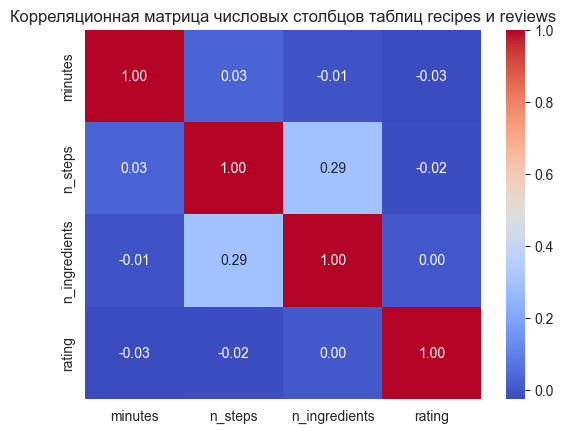

In [53]:
sns.heatmap(new_table.corr(), annot=True, fmt='.2f', cmap='coolwarm') # строим тепловую карту
plt.title('Корреляционная матрица числовых столбцов таблиц recipes и reviews', verticalalignment='baseline');
new_table.corr()